# Notebook 05 – Baseline Forecasting Setup

## Objective
Set up a simple baseline forecasting model for ozone exceedance days to establish a reference point for future predictive models.  

This will help evaluate the improvements gained by more advanced models later on.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

plt.style.use("seaborn-v0_8")
sns.set_context("notebook")

In [2]:
DATA_PATH = "../data/processed/air_quality_data_processed.csv"
df = pd.read_csv(DATA_PATH)

df.head()

,state_fips,state,county_fips,county,year,measure_id,measure_name,value,data_origin,monitor_only,value_missing,value_lag_1,value_lag_3,rolling_mean_3,year_norm,high_risk
0,1,Alabama,1001,Autauga,2001,292,Number of days with maximum 8-hour average ozo...,3.000000,Monitor & Modeled,False,0,NaN,NaN,NaN,2,0
1,1,Alabama,1001,Autauga,2001,293,Number of person-days with maximum 8-hour aver...,134667.000000,Monitor & Modeled,False,0,3.0,NaN,NaN,2,1
2,1,Alabama,1001,Autauga,2001,294,Percent of days with PM2.5 levels over the Nat...,0.000000,Monitor & Modeled,False,0,134667.0,NaN,44890.000000,2,0
3,1,Alabama,1001,Autauga,2001,295,Number of person-days with PM2.5 over the Nati...,0.000000,Monitor & Modeled,False,0,0.0,3.0,44889.000000,2,0
4,1,Alabama,1001,Autauga,2001,296,Annual average ambient concentrations of PM 2....,13.186807,Monitor & Modeled,False,0,0.0,134667.0,4.395602,2,0


In [3]:
df.columns.tolist()

['state_fips',
 'state',
 'county_fips',
 'county',
 'year',
 'measure_id',
 'measure_name',
 'value',
 'data_origin',
 'monitor_only',
 'value_missing',
 'value_lag_1',
 'value_lag_3',
 'rolling_mean_3',
 'year_norm',
 'high_risk']

In [4]:
df.shape

(218635, 16)

**Bulletproof Data Filtering**

To resolve the "billion-scale" error, we implement a strict filter that ensures both the current value and the lag value are within the logical range of annual days (0-365).

In [9]:
mask = (df['measure_name'].str.contains('Ozone', case=False)) & \
        (df['measure_name'].str.contains('days', case=False)) & \
        (~df['measure_name'].str.contains('person', case=False)) & \
        (df['value'] <= 365) & \
        (df['value_lag_1'] <= 365)

df_final = df[mask].dropna(subset=["value", "value_lag_1"])

print(f"Verified Max Value in Data: {df_final['value'].max()}")
print(f"Verified Max Value in Lag: {df_final['value_lag_1'].max()}")

Verified Max Value in Data: 146.0
Verified Max Value in Lag: 33.0


**Baseline Model Execution**

We use the Persistence Method, where the forecast for year $t$ is simply the value from year $t-1$.

In [10]:
X = df_final[["value_lag_1"]]
y = df_final["value"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

y_pred_base = X_test["value_lag_1"].values

**Final Results & Comparison**

The metrics now reflect a human-readable scale in "Days".

Baseline R2: -0.1593
Baseline MAE: 8.47 Days


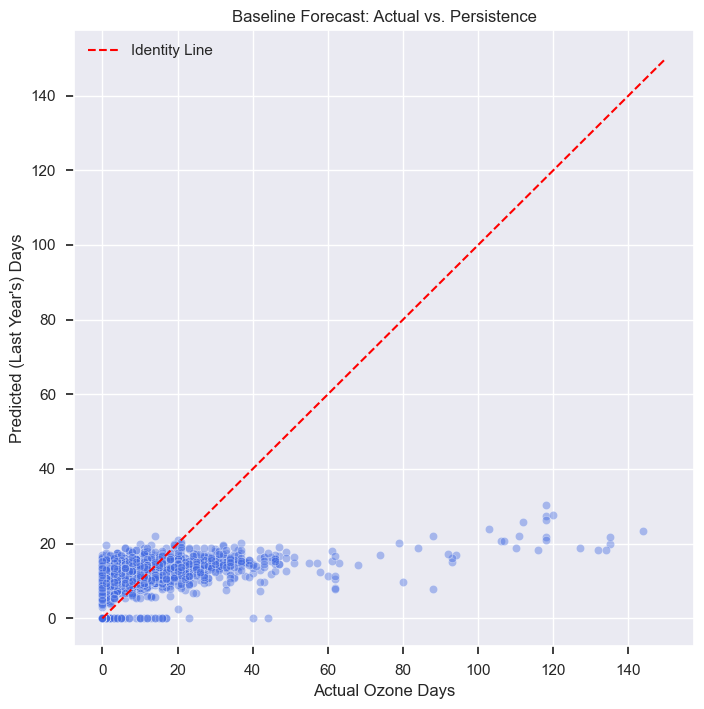

In [13]:
r2_base = r2_score(y_test, y_pred_base)
mae_base = mean_absolute_error(y_test, y_pred_base)

print(f"Baseline R2: {r2_base:.4f}")
print(f"Baseline MAE: {mae_base:.2f} Days")

plt.figure(figsize=(8, 8))
sns.scatterplot(x=y_test, y=y_pred_base, alpha=0.4, color='royalblue')
plt.plot([0, 150], [0, 150], linestyle="--", color="red", label="Identity Line")
plt.xlabel("Actual Ozone Days")
plt.ylabel("Predicted (Last Year's) Days")
plt.title("Baseline Forecast: Actual vs. Persistence")
plt.legend()
plt.show()

## Next Steps

- Compare baseline performance to Random Forest and other advanced models.
- Extend features: `value_lag_3`, `rolling_mean_3`, `year_norm`.
- Consider spatial features (state/county) for regional predictions.
- Use baseline results as a reference for early-warning system evaluation.
